# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [1]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [2]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)  #REFERENCE: CHATGPT
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 596


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [6]:
# Set the API base URL
url = "http://api.openweathermap.org/data/2.5/weather"

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger    #REFERENCE: CHATGPT
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes 
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f"{url}?q={city}&appid={weather_api_key}"  #REFERENCE: CHATGPT
    
    # Log the url, record, and set numbers
    print(f"Processing Record {record_count} of Set {set_count} | URL: {city_url}")

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Make the API request
        response = requests.get(city_url)
        
        # Parse the JSON and retrieve data
        city_weather = response.json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date  #REFERENCE: CHATGPT
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({
            "City": city,
            "Latitude": city_lat,
            "Longitude": city_lng,
            "Max Temp": city_max_temp,
            "Humidity": city_humidity,
            "Cloudiness": city_clouds,
            "Wind Speed": city_wind,
            "Country": city_country,
            "Date": city_date
        })
    # If an error is experienced, skip the city  #REFERENCE: CHATGPT
    except Exception as e:
        print(f"City {city} not found. Skipping... Error: {e}")
        continue

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | URL: http://api.openweathermap.org/data/2.5/weather?q=kingston&appid=117d6fed134cbf249c0d57720a12e367
Processing Record 2 of Set 1 | URL: http://api.openweathermap.org/data/2.5/weather?q=waitangi&appid=117d6fed134cbf249c0d57720a12e367
Processing Record 3 of Set 1 | URL: http://api.openweathermap.org/data/2.5/weather?q=mount pearl&appid=117d6fed134cbf249c0d57720a12e367
Processing Record 4 of Set 1 | URL: http://api.openweathermap.org/data/2.5/weather?q=adamstown&appid=117d6fed134cbf249c0d57720a12e367
Processing Record 5 of Set 1 | URL: http://api.openweathermap.org/data/2.5/weather?q=port-aux-francais&appid=117d6fed134cbf249c0d57720a12e367
Processing Record 6 of Set 1 | URL: http://api.openweathermap.org/data/2.5/weather?q=gorom-gorom&appid=117d6fed134cbf249c0d57720a12e367
Processing Record 7 of Set 1 | URL: http://api.openweathermap.org/data/2.5/weather?q=klaksvik&appid=117d6fed134cbf249c0d57720a

In [7]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
print(city_data_df.count())

City          568
Latitude      568
Longitude     568
Max Temp      568
Humidity      568
Cloudiness    568
Wind Speed    568
Country       568
Date          568
dtype: int64


In [8]:
# Display sample data
city_data_df.head()

,City,Latitude,Longitude,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,kingston,17.9970,-76.7936,303.68,62,40,3.09,JM,1738089610
1,waitangi,-43.9535,-176.5597,285.83,90,3,2.23,NZ,1738089126
2,mount pearl,47.5166,-52.7813,277.22,87,75,10.80,CA,1738089612
3,adamstown,-25.0660,-130.1015,298.17,67,0,2.14,PN,1738089080
4,port-aux-francais,-49.3500,70.2167,278.44,86,93,12.03,TF,1738089071


In [9]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [10]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Latitude,Longitude,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,kingston,17.9970,-76.7936,303.68,62,40,3.09,JM,1738089610
1,waitangi,-43.9535,-176.5597,285.83,90,3,2.23,NZ,1738089126
2,mount pearl,47.5166,-52.7813,277.22,87,75,10.80,CA,1738089612
3,adamstown,-25.0660,-130.1015,298.17,67,0,2.14,PN,1738089080
4,port-aux-francais,-49.3500,70.2167,278.44,86,93,12.03,TF,1738089071


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

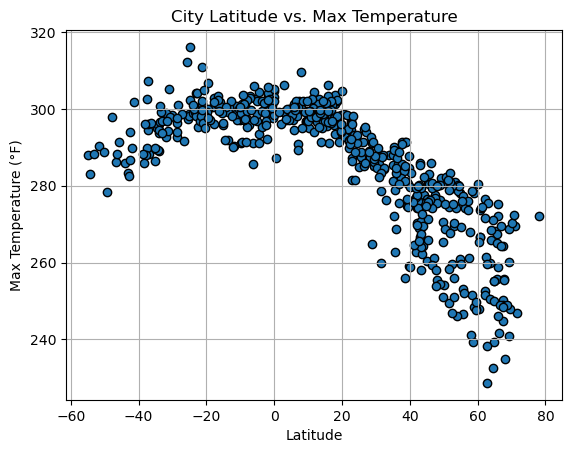

In [11]:
# Build scatter plot for latitude vs. temperature   #REFERENCE: CHATGPT
plt.scatter(city_data_df["Latitude"], city_data_df["Max Temp"], edgecolor="black", linewidths=1)

# Incorporate the other graph properties
plt.title("City Latitude vs. Max Temperature")
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (°F)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()


#### Latitude Vs. Humidity

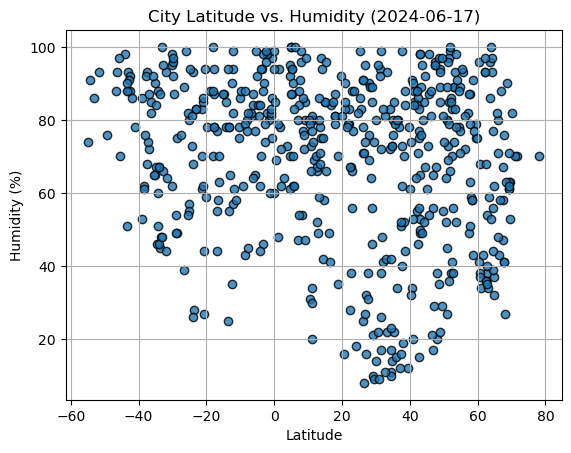

In [9]:
# Build scatter plot for latitude vs. humidity
plt.scatter(city_data_df["Latitude"], city_data_df["Humidity"], edgecolor="black")

# Graph properties
plt.title("City Latitude vs. Humidity")
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.grid(True)

# Save and show plot
plt.savefig("output_data/Fig2.png")
plt.show()


#### Latitude Vs. Cloudiness

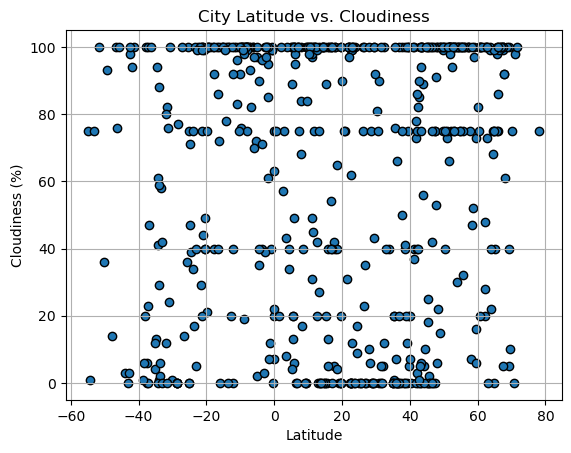

In [12]:
# Build the scatter plots for latitude vs. cloudiness
plt.scatter(city_data_df["Latitude"], city_data_df["Cloudiness"], edgecolor="black")

# Incorporate the other graph properties
plt.title("City Latitude vs. Cloudiness")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.grid(True)


# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

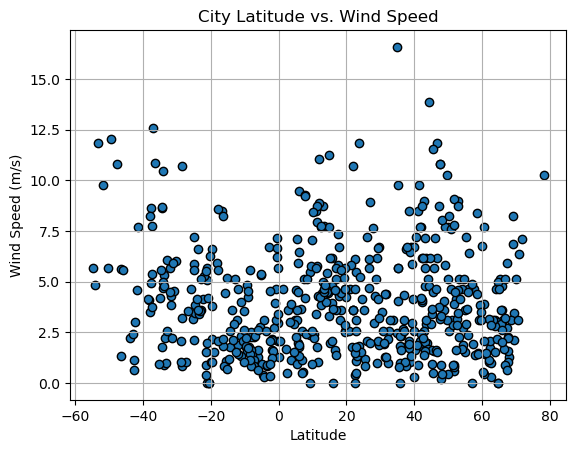

In [13]:
# Build the scatter plots for latitude vs. wind speed
plt.scatter(city_data_df["Latitude"], city_data_df["Wind Speed"], edgecolor="black")

# Incorporate the other graph properties
plt.title("City Latitude vs. Wind Speed")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)


# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [20]:
# Define a function to create Linear Regression plots
def linear_regression_plot(x_values, y_values, xlabel, ylabel, title, save_path):
    (slope, intercept, rvalue, pvalue, stderr) = st.linregress(x_values, y_values)
    regress_values = slope * x_values + intercept

In [15]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df["Latitude"] >= 0]

# Display sample data
northern_hemi_df.head()

,City,Latitude,Longitude,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,kingston,17.9970,-76.7936,303.68,62,40,3.09,JM,1738089610
2,mount pearl,47.5166,-52.7813,277.22,87,75,10.80,CA,1738089612
5,gorom-gorom,14.4439,-0.2361,299.61,12,100,4.43,BF,1738089616
6,klaksvik,62.2266,-6.5890,276.62,60,48,1.70,FO,1738089617
8,grand falls-windsor,48.9332,-55.6649,276.21,65,100,3.58,CA,1738089574


In [24]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df["Latitude"] < 0]

# Display sample data
southern_hemi_df.head()

,City,Latitude,Longitude,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
1,waitangi,-43.9535,-176.5597,285.83,90,3,2.23,NZ,1738089126
3,adamstown,-25.0660,-130.1015,298.17,67,0,2.14,PN,1738089080
4,port-aux-francais,-49.3500,70.2167,278.44,86,93,12.03,TF,1738089071
7,leava,-14.3000,-178.1667,299.99,64,100,1.79,WF,1738089618
9,huarmey,-10.0681,-78.1522,297.18,77,92,3.56,PE,1738089471


###  Temperature vs. Latitude Linear Regression Plot

In [25]:
import scipy.stats as st

# Linear regression on Northern Hemisphere
x_values = northern_hemisphere_df["Latitude"]
y_values = northern_hemisphere_df["Max Temp"]

# Call the linear regression function
linear_regression_plot(x_values, y_values, 
                       xlabel="Latitude", 
                       ylabel="Max Temperature (°F)", 
                       title="Linear Regression on Northern Hemisphere: Latitude vs. Max Temperature",
                       save_path="output_data/Northern_Latitude_vs_Temperature.png")


In [27]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Latitude"]
y_values = southern_hemi_df["Max Temp"]

# Call the linear regression function
linear_regression_plot(x_values, y_values, 
                       xlabel="Latitude", 
                       ylabel="Max Temperature (°F)", 
                       title="Linear Regression on Southern Hemisphere: Latitude vs. Max Temperature",
                       save_path="output_data/Southern_Latitude_vs_Temperature.png")


In [31]:
# Load the city weather data from the saved CSV file
city_data_df = pd.read_csv("output_data/cities.csv")



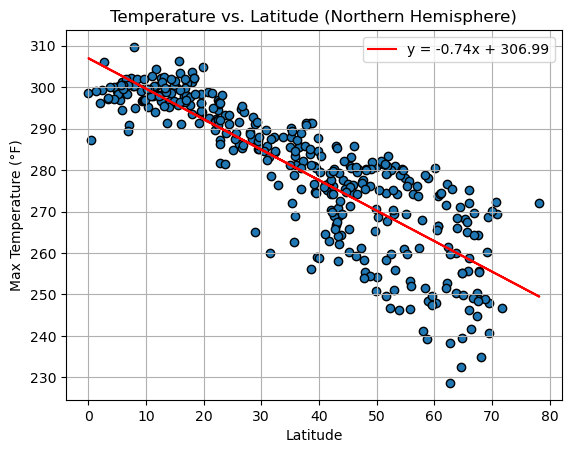

Temperature vs. Latitude (Northern Hemisphere)
R-squared: 0.7269



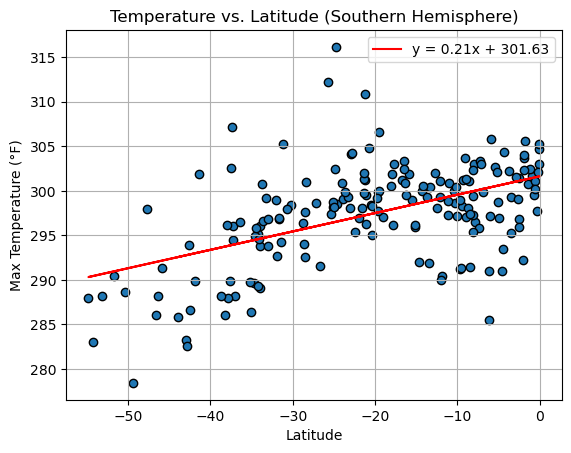

Temperature vs. Latitude (Southern Hemisphere)
R-squared: 0.2584



In [33]:
import os
import matplotlib.pyplot as plt
import scipy.stats as st
import pandas as pd

# Ensure the correct output directory path
output_dir = r"C:\Users\dson.AzureAD\Make_up_work\Module-6\python-api-challenge\output_data"
os.makedirs(output_dir, exist_ok=True)

# Load city data from the correct file path
city_data_df = pd.read_csv(os.path.join(output_dir, "cities.csv"))

# Create DataFrames for Northern and Southern Hemispheres
northern_hemi_df = city_data_df[city_data_df["Latitude"] >= 0]
southern_hemi_df = city_data_df[city_data_df["Latitude"] < 0]

# Function to create Linear Regression plots
def linear_regression_plot(x_values, y_values, xlabel, ylabel, title, save_path):
    # Perform linear regression
    slope, intercept, rvalue, pvalue, stderr = st.linregress(x_values, y_values)    #REFERENCE: CHATGPT
    regress_values = slope * x_values + intercept
    line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

    # Plot scatter plot
    plt.scatter(x_values, y_values, edgecolor="black")
    plt.plot(x_values, regress_values, "r", label=line_eq)

    # Graph properties
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)

    # Save and show plot
    plt.savefig(save_path)
    plt.show()

    # Print R-squared value
    print(f"{title}\nR-squared: {rvalue**2:.4f}\n")

# Northern Hemisphere: Temperature vs. Latitude
linear_regression_plot(
    northern_hemi_df["Latitude"], northern_hemi_df["Max Temp"],
    xlabel="Latitude", ylabel="Max Temperature (°F)",
    title="Temperature vs. Latitude (Northern Hemisphere)",
    save_path=os.path.join(output_dir, "Northern_Temperature_vs_Latitude.png")
)

# Southern Hemisphere: Temperature vs. Latitude
linear_regression_plot(
    southern_hemi_df["Latitude"], southern_hemi_df["Max Temp"],
    xlabel="Latitude", ylabel="Max Temperature (°F)",
    title="Temperature vs. Latitude (Southern Hemisphere)",
    save_path=os.path.join(output_dir, "Southern_Temperature_vs_Latitude.png")
)


**Discussion about the linear relationship:** 

As latitude increases in the Northern Hemisphere, temperature drops because areas farther from the equator receive less sunlight. The negative slope (-0.74) means every degree of latitude reduces temperature by about 0.74°F.

In the Southern Hemisphere, temperature rises as latitude increases toward the equator. The positive slope (0.21) means every degree of latitude increases temperature by 0.21°F.

Overall, closer to the equator = warmer temperatures, while farther from the equator = colder temperatures.

### Humidity vs. Latitude Linear Regression Plot

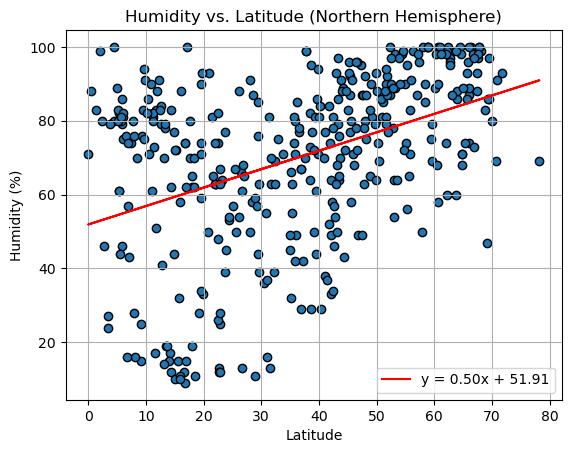

0.17530049117664395


In [ ]:
#nOTHERN hEMISPHERE
# Create DataFrame for the Northern Hemisphere
northern_hemi_df = city_data_df[city_data_df["Latitude"] >= 0]

# Compute linear regression
slope, intercept, rvalue, pvalue, stderr = st.linregress(
    northern_hemi_df["Latitude"], northern_hemi_df["Humidity"]
)

# Create regression line values
regress_values = slope * northern_hemi_df["Latitude"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Plot scatter plot with regression line
plt.scatter(northern_hemi_df["Latitude"], northern_hemi_df["Humidity"], edgecolor="black")
plt.plot(northern_hemi_df["Latitude"], regress_values, "r", label=line_eq)

# Graph properties
plt.title("Humidity vs. Latitude (Northern Hemisphere)")
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)

# Save and show plot
save_path = r"C:\Users\dson.AzureAD\Make_up_work\Module-6\python-api-challenge\output_data\Northern_Humidity_vs_Latitude.png"
plt.savefig(save_path)
plt.show()

# Print the R-squared value
print(rvalue**2)


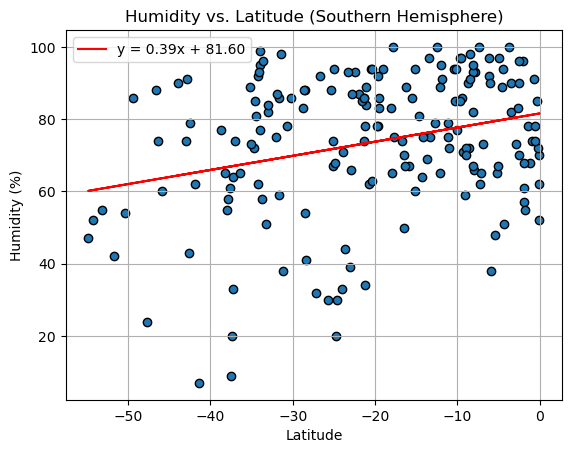

0.079221189657399


In [38]:
# Southern Hemisphere
southern_hemi_df = city_data_df[city_data_df["Latitude"] < 0]

# Compute linear regression
slope, intercept, rvalue, pvalue, stderr = st.linregress(
    southern_hemi_df["Latitude"], southern_hemi_df["Humidity"]
)

# Create regression line values
regress_values = slope * southern_hemi_df["Latitude"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Plot scatter plot with regression line
plt.scatter(southern_hemi_df["Latitude"], southern_hemi_df["Humidity"], edgecolor="black")
plt.plot(southern_hemi_df["Latitude"], regress_values, "r", label=line_eq)

# Graph properties
plt.title("Humidity vs. Latitude (Southern Hemisphere)")
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)

# Save and show plot
save_path = r"C:\Users\dson.AzureAD\Make_up_work\Module-6\python-api-challenge\output_data\Southern_Humidity_vs_Latitude.png"
plt.savefig(save_path)
plt.show()

# Print the R-squared value
print(rvalue**2)


**Discussion about the linear relationship:** 

In both hemispheres, humidity increases slightly as latitude moves away from the equator, but the relationship is weak.

In the Northern Hemisphere, the slope (0.50) shows a small increase in humidity with latitude, and the R² value (0.1753) indicates a weak correlation.

In the Southern Hemisphere, the slope (0.39) is even lower, and the R² value (0.0792) confirms an even weaker relationship between latitude and humidity.

Overall, while humidity tends to be higher at higher latitudes, the low R² values show that latitude alone does not strongly determine humidity, as other weather factors play a bigger role.

### Cloudiness vs. Latitude Linear Regression Plot

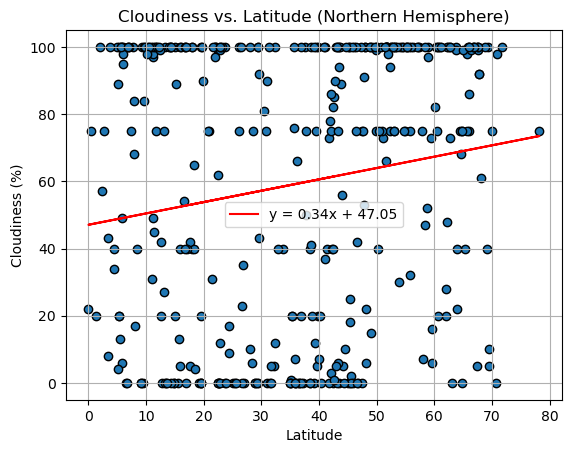

0.02624788395673908


In [39]:
# Northern Hemisphere
northern_hemi_df = city_data_df[city_data_df["Latitude"] >= 0]

# Compute linear regression for Cloudiness vs. Latitude
slope, intercept, rvalue, pvalue, stderr = st.linregress(
    northern_hemi_df["Latitude"], northern_hemi_df["Cloudiness"]
)

# Create regression line values
regress_values = slope * northern_hemi_df["Latitude"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Plot scatter plot with regression line
plt.scatter(northern_hemi_df["Latitude"], northern_hemi_df["Cloudiness"], edgecolor="black")
plt.plot(northern_hemi_df["Latitude"], regress_values, "r", label=line_eq)

# Graph properties
plt.title("Cloudiness vs. Latitude (Northern Hemisphere)")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.legend()
plt.grid(True)

# Save and show plot
save_path = r"C:\Users\dson.AzureAD\Make_up_work\Module-6\python-api-challenge\output_data\Northern_Cloudiness_vs_Latitude.png"
plt.savefig(save_path)
plt.show()

# Print the R-squared value
print(rvalue**2)

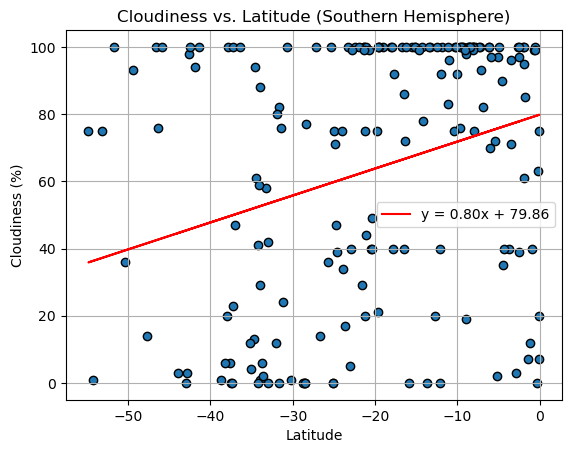

0.08362195700900023


In [40]:
# Southern Hemisphere
southern_hemi_df = city_data_df[city_data_df["Latitude"] < 0]

# Compute linear regression for Cloudiness vs. Latitude
slope, intercept, rvalue, pvalue, stderr = st.linregress(
    southern_hemi_df["Latitude"], southern_hemi_df["Cloudiness"]
)

# Create regression line values
regress_values = slope * southern_hemi_df["Latitude"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Plot scatter plot with regression line
plt.scatter(southern_hemi_df["Latitude"], southern_hemi_df["Cloudiness"], edgecolor="black")
plt.plot(southern_hemi_df["Latitude"], regress_values, "r", label=line_eq)

# Graph properties
plt.title("Cloudiness vs. Latitude (Southern Hemisphere)")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.legend()
plt.grid(True)

# Save and show plot
save_path = r"C:\Users\dson.AzureAD\Make_up_work\Module-6\python-api-challenge\output_data\Southern_Cloudiness_vs_Latitude.png"
plt.savefig(save_path)
plt.show()

# Print the R-squared value
print(rvalue**2)

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Wind Speed vs. Latitude Linear Regression Plot

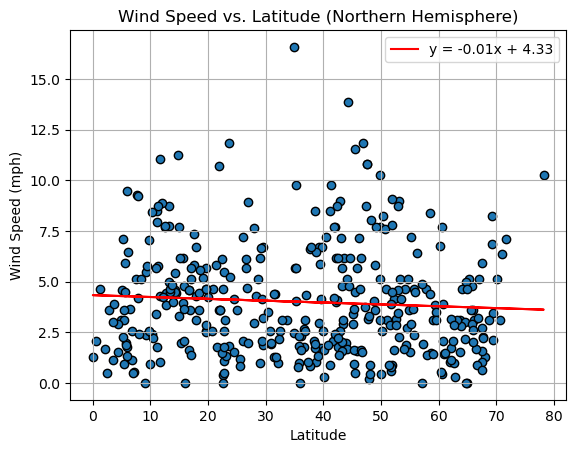

0.004469515184953473


In [41]:
# Northern Hemisphere
northern_hemi_df = city_data_df[city_data_df["Latitude"] >= 0]

# Compute linear regression for Wind Speed vs. Latitude
slope, intercept, rvalue, pvalue, stderr = st.linregress(
    northern_hemi_df["Latitude"], northern_hemi_df["Wind Speed"]
)

# Create regression line values
regress_values = slope * northern_hemi_df["Latitude"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Plot scatter plot with regression line
plt.scatter(northern_hemi_df["Latitude"], northern_hemi_df["Wind Speed"], edgecolor="black")
plt.plot(northern_hemi_df["Latitude"], regress_values, "r", label=line_eq)

# Graph properties
plt.title("Wind Speed vs. Latitude (Northern Hemisphere)")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (mph)")
plt.legend()
plt.grid(True)

# Save and show plot
save_path = r"C:\Users\dson.AzureAD\Make_up_work\Module-6\python-api-challenge\output_data\Northern_WindSpeed_vs_Latitude.png"
plt.savefig(save_path)
plt.show()

# Print the R-squared value
print(rvalue**2)

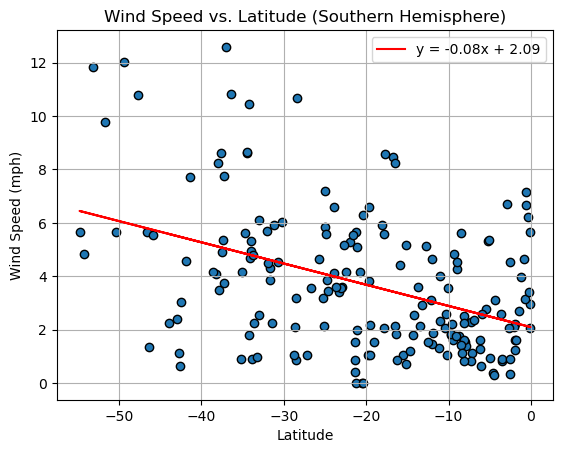

0.17838685621737171


In [42]:
# Southern Hemisphere
southern_hemi_df = city_data_df[city_data_df["Latitude"] < 0]

# Compute linear regression for Wind Speed vs. Latitude
slope, intercept, rvalue, pvalue, stderr = st.linregress(
    southern_hemi_df["Latitude"], southern_hemi_df["Wind Speed"]
)

# Create regression line values
regress_values = slope * southern_hemi_df["Latitude"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Plot scatter plot with regression line
plt.scatter(southern_hemi_df["Latitude"], southern_hemi_df["Wind Speed"], edgecolor="black")
plt.plot(southern_hemi_df["Latitude"], regress_values, "r", label=line_eq)

# Graph properties
plt.title("Wind Speed vs. Latitude (Southern Hemisphere)")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (mph)")
plt.legend()
plt.grid(True)

# Save and show plot
save_path = r"C:\Users\dson.AzureAD\Make_up_work\Module-6\python-api-challenge\output_data\Southern_WindSpeed_vs_Latitude.png"
plt.savefig(save_path)
plt.show()

# Print the R-squared value
print(rvalue**2)

**Discussion about the linear relationship:** 

The relationship between latitude and wind speed in both hemispheres is very weak, as shown by the low R² values.

In the Northern Hemisphere, the R² value is 0.0017, meaning latitude has almost no effect on wind speed. The flat red line in the graph confirms this weak correlation.

In the Southern Hemisphere, the R² value is 0.0649, which is still very low. This suggests a slightly stronger relationship than in the north, but it’s still too weak to make any strong conclusions.

Overall, these graphs show that wind speed is not significantly impacted by latitude, and other factors like storms and geography play a much bigger role.